In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.integrate import trapezoid
from scipy.interpolate import interp1d
from IPython.display import Video

import imageio_ffmpeg
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

import atomic_scf
import potentials as pot
import shells
import scf
import scf_movie
import spectra
import hydrogenic as hy

In [2]:
res = scf.run_scf(26, record_history=True, verbose=False)
print(f"Ar: {res['iterations']} iterations, E_total = {res['E_total']:.5f} Ha, "
      f"config = {shells.format_configuration(res['config'])}")
print(f"{len(res['snapshots'])} snapshots recorded")

Ar: 47 iterations, E_total = -1261.39173 Ha, config = 1s2 2s2 2p6 3s2 3p6 3d6 4s2
47 snapshots recorded


In [3]:
movie_path = scf_movie.make_scf_animation(
    res, "Iron (Z=18)", "media/scf_convergence_Fe.mp4"
)
print("saved:", movie_path)
Video(movie_path, embed=True, html_attributes="controls loop")

saved: media/scf_convergence_Fe.mp4


In [4]:
r_grid = res['r']
R_interp = {nl: interp1d(r_grid, R_nl, bounds_error=False, fill_value=0.0)
            for nl, R_nl in res['orbitals'].items()}
print("occupied subshells:", sorted(R_interp.keys(), key=lambda nl: (nl[0], nl[1])))

occupied subshells: [(1, 0), (2, 0), (2, 1), (3, 0), (3, 1), (3, 2), (4, 0)]


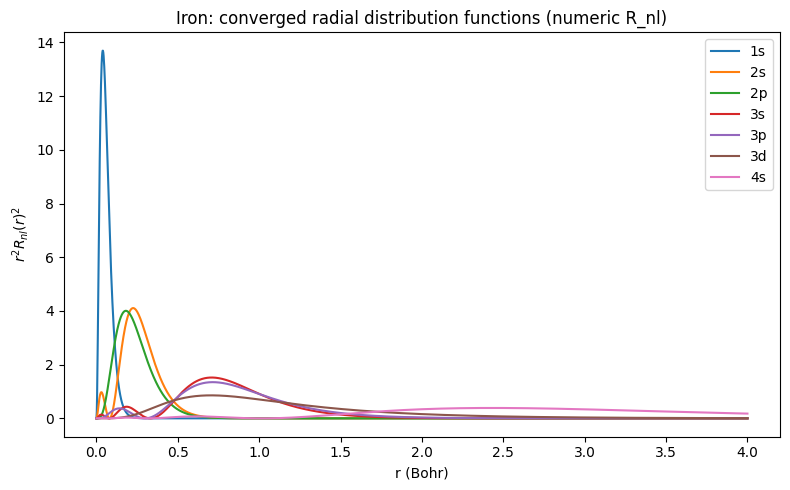

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for (n, l), R_func in sorted(R_interp.items()):
    hy.plot_radial_density(n, l, Z=18, r_max=4, ax=ax, R_func=R_func, label=f"{n}{'spdf'[l]}")
ax.set_title("Iron: converged radial distribution functions (numeric R_nl)")
ax.legend()
plt.tight_layout()
fig.savefig("media/radial_density_Fe.png", dpi=110)
plt.show()

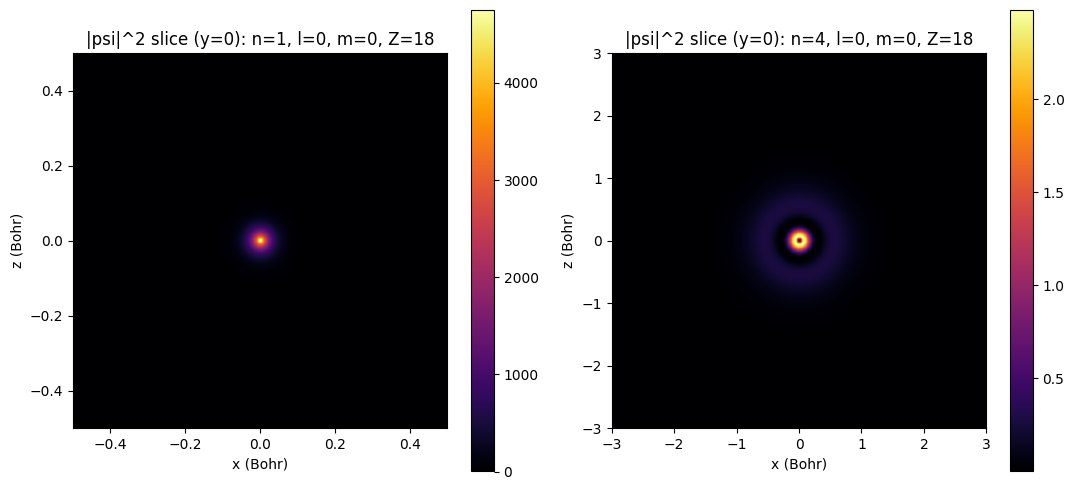

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(11, 5))
hy.plot_orbital_density_slice(1, 0, 0, Z=18, extent=0.5, ax=axs[0], R_func=R_interp[(1, 0)])
hy.plot_orbital_density_slice(4, 0, 0, Z=18, extent=3.0, ax=axs[1], R_func=R_interp[(3, 1)])
plt.tight_layout()
fig.savefig("media/density_slices_Fe.png", dpi=110)
plt.show()

In [15]:
name = 'Fe'
levels, lines = spectra.atomic_spectrum(res, l_max=5, n_states=10)
results, all_lines, all_levels = {}, {}, {}
exp_nm = 600

results[name], all_lines[name], all_levels[name] = res, lines, levels
ln = lines[0]
err = (ln['wavelength_nm'] - exp_nm) / exp_nm * 100
trans = f"{ln['upper']}->{ln['lower']}"
print(f"{name:4s} {shells.format_configuration(res['config']):24s} {trans:12s} "
      f"{ln['wavelength_nm']:15.1f} {exp_nm:16.1f} {err:7.1f}%")

Fe   1s2 2s2 2p6 3s2 3p6 3d6 4s2 (4, 1)->(3, 2)           194.0            600.0   -67.7%


In [16]:
print(lines)

[{'upper': (4, 1), 'lower': (3, 2), 'delta_E_hartree': np.float64(0.23488255885399667), 'energy_eV': np.float64(6.391480031422112), 'wavelength_nm': np.float64(193.98354970001154)}]


<Axes: title={'center': 'Fe: predicted emission line(s)'}, xlabel='wavelength (nm)'>

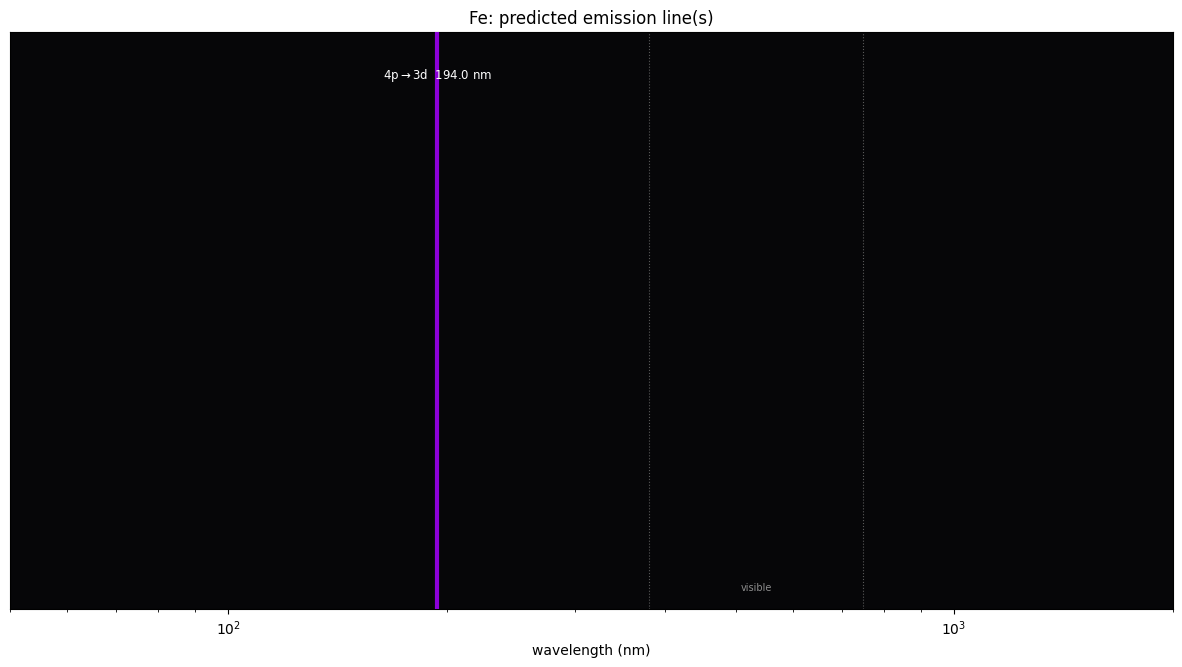

In [17]:
fig, ax = plt.subplots(figsize=(15, 7.5))
spectra.plot_spectrum(all_lines[name], ax=ax, atom_label=name)